In [ ]:
# --- Load CUDA module (if on HPC) ---
!module load CUDA/12.6.0

# --- Persist environment variables for this Python process ---
import os

os.environ["CUDA_HOME"] = "/apps/common/software/CUDA/12.6.0"
os.environ["PATH"] = f"{os.environ['CUDA_HOME']}/bin:" + os.environ["PATH"]
os.environ["LD_LIBRARY_PATH"] = f"{os.environ['CUDA_HOME']}/lib64:" + os.environ.get("LD_LIBRARY_PATH", "")

# --- Verify ---
!which nvcc
!nvidia-smi
# import tensorflow as tf
# print(tf.config.list_physical_devices('GPU'))

/apps/common/software/CUDA/12.6.0/bin/nvcc
Fri Nov 28 13:56:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          On  |   00000000:CB:00.0 Off |                    0 |
| N/A   40C    P0             62W /  400W |       1MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+----

Dataset downloaded to: /home/rameyjm7/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1
Images directory: /home/rameyjm7/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1/images
XML directory: /home/rameyjm7/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1/annotations
Total images found: 433


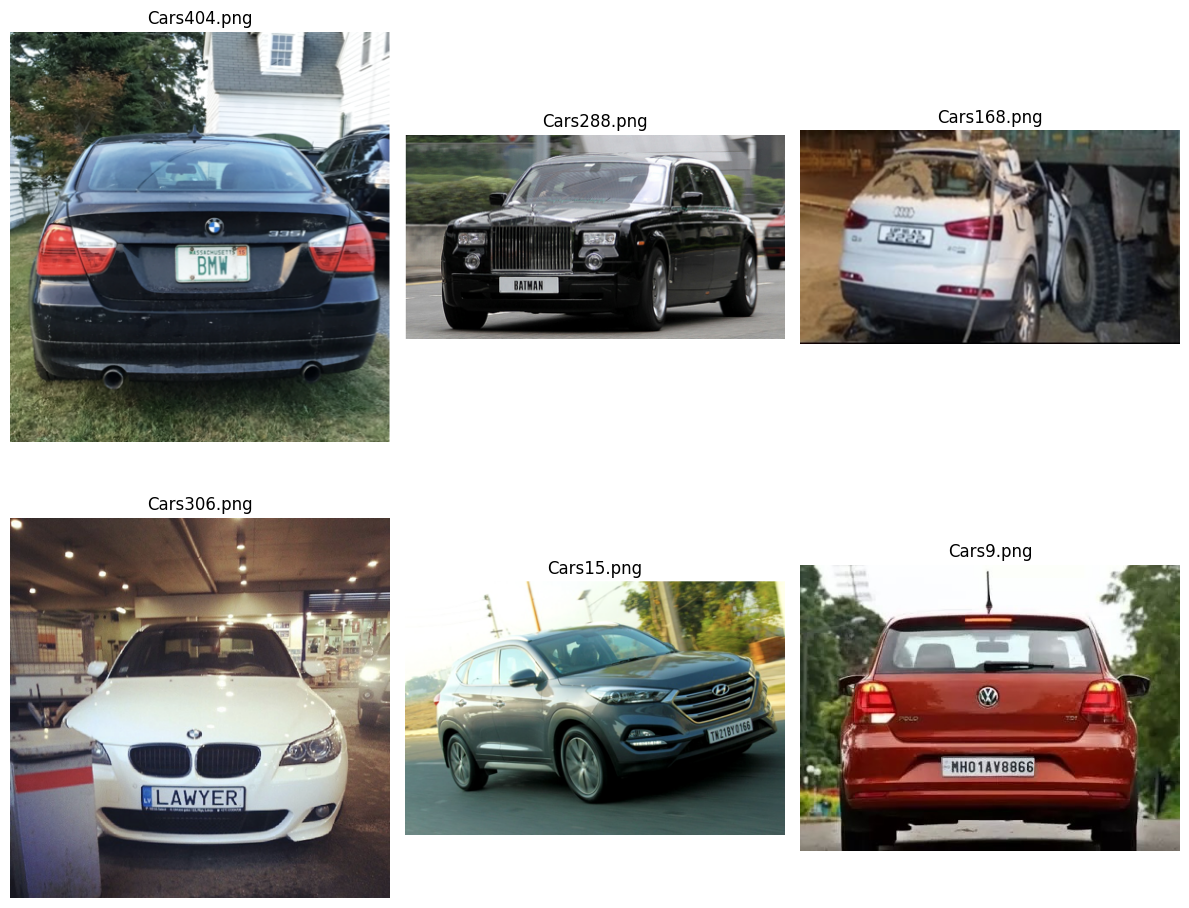

In [2]:
import os
import random
from pathlib import Path
import kagglehub
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ----------------------------------------------------------------------
# 1. Download dataset
# ----------------------------------------------------------------------
dataset_path = kagglehub.dataset_download("andrewmvd/car-plate-detection")
root = Path(dataset_path)

img_dir = root / "images"
xml_dir = root / "annotations"

print("Dataset downloaded to:", root)
print("Images directory:", img_dir)
print("XML directory:", xml_dir)

# ----------------------------------------------------------------------
# 2. List all image files
# ----------------------------------------------------------------------
image_paths = sorted(list(img_dir.glob("*.*")))
print("Total images found:", len(image_paths))

# ----------------------------------------------------------------------
# 3. Choose N random images to display
# ----------------------------------------------------------------------
N = 6
sample_paths = random.sample(image_paths, min(N, len(image_paths)))

# ----------------------------------------------------------------------
# 4. Display images in a grid
# ----------------------------------------------------------------------
cols = 3
rows = (N + cols - 1) // cols

plt.figure(figsize=(12, 10))

for i, img_path in enumerate(sample_paths):
    plt.subplot(rows, cols, i + 1)
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [3]:
# ============================================================
# YOLO DATASET MERGE (IDEMPOTENT)
# ============================================================

import os
import glob
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path
import kagglehub

# -----------------------------
# Directories
# -----------------------------
OUT_ROOT = Path("combined_yolo_lp")
IM_TRAIN = OUT_ROOT / "images/train"
IM_VAL   = OUT_ROOT / "images/val"
LB_TRAIN = OUT_ROOT / "labels/train"
LB_VAL   = OUT_ROOT / "labels/val"
DATA_YAML = OUT_ROOT / "data.yaml"

# -----------------------------
# If already done ➜ SKIP
# -----------------------------
if OUT_ROOT.exists() and IM_TRAIN.exists() and IM_VAL.exists() and LB_TRAIN.exists() and LB_VAL.exists():
    print("============================================================")
    print("   MERGED YOLO DATASET ALREADY PRESENT — SKIPPING WORK")
    print("============================================================")
    print("Directory:", OUT_ROOT.resolve())
    print("Data YAML:", DATA_YAML.resolve())
else:
    print("============================================================")
    print("   BUILDING MERGED YOLO DATASET (FIRST TIME)")
    print("============================================================")

    # Create dirs
    (OUT_ROOT / "images/train").mkdir(parents=True, exist_ok=True)
    (OUT_ROOT / "images/val").mkdir(parents=True, exist_ok=True)
    (OUT_ROOT / "labels/train").mkdir(parents=True, exist_ok=True)
    (OUT_ROOT / "labels/val").mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------------------
    # 1. Download datasets
    # ------------------------------------------------------------
    print("Downloading datasets...")
    dsetA = kagglehub.dataset_download("andrewmvd/car-plate-detection")
    dsetB = kagglehub.dataset_download("ronakgohil/license-plate-dataset")

    rootA = Path(dsetA)
    rootB = Path(dsetB) / "archive"

    print("Dataset A:", rootA)
    print("Dataset B:", rootB)

    # ------------------------------------------------------------
    # 2. Convert Dataset A (VOC XML) → YOLO
    # ------------------------------------------------------------
    print("Converting Dataset A XML → YOLO format...")

    imgA = rootA / "images"
    xmlA = rootA / "annotations"

    xml_files = sorted(xmlA.glob("*.xml"))
    split_idx = int(0.8 * len(xml_files))

    def voc_to_yolo(img_path, box, save_label_path):
        import cv2
        img = cv2.imread(str(img_path))
        h, w = img.shape[:2]

        xmin, ymin, xmax, ymax = box
        x_c = (xmin + xmax) / 2 / w
        y_c = (ymin + ymax) / 2 / h
        bw = (xmax - xmin) / w
        bh = (ymax - ymin) / h

        with open(save_label_path, "a") as f:
            f.write(f"0 {x_c} {y_c} {bw} {bh}\n")

    for i, xml_file in enumerate(xml_files):
        tree = ET.parse(xml_file)
        root_xml = tree.getroot()
        filename = root_xml.find("filename").text
        img_path = imgA / filename

        if i < split_idx:
            img_out = IM_TRAIN / filename
            lbl_out = LB_TRAIN / (filename.replace(".png", ".txt"))
        else:
            img_out = IM_VAL / filename
            lbl_out = LB_VAL / (filename.replace(".png", ".txt"))

        shutil.copy(img_path, img_out)

        for obj in root_xml.findall("object"):
            if obj.find("name").text.strip() != "licence":
                continue

            b = obj.find("bndbox")
            xmin = float(b.find("xmin").text)
            ymin = float(b.find("ymin").text)
            xmax = float(b.find("xmax").text)
            ymax = float(b.find("ymax").text)

            voc_to_yolo(img_out, (xmin, ymin, xmax, ymax), lbl_out)

    print("Dataset A conversion complete.")

    # ------------------------------------------------------------
    # 3. Merge Dataset B (already YOLO format)
    # ------------------------------------------------------------
    print("Merging Dataset B...")

    for split in ["train", "val"]:
        img_src = rootB / "images" / split
        lbl_src = rootB / "labels" / split

        for img_file in img_src.glob("*.*"):
            shutil.copy(img_file, OUT_ROOT / f"images/{split}" / img_file.name)

        for lbl_file in lbl_src.glob("*.txt"):
            shutil.copy(lbl_file, OUT_ROOT / f"labels/{split}" / lbl_file.name)

    print("Dataset B merged.")

    # ------------------------------------------------------------
    # 4. Write absolute-path data.yaml
    # ------------------------------------------------------------
    train_path = str(IM_TRAIN.resolve())
    val_path   = str(IM_VAL.resolve())

    DATA_YAML.write_text(
        f"train: {train_path}\n"
        f"val: {val_path}\n\n"
        "nc: 1\n"
        "names: ['license_plate']\n"
    )

    print("Written data.yaml:", DATA_YAML.resolve())

print("Dataset merge step complete.")
print("Ready for training in next cell.")

# ------------------------------------------------------------
# 5. Summary of dataset contents
# ------------------------------------------------------------
train_imgs = sorted(IM_TRAIN.glob("*.*"))
val_imgs   = sorted(IM_VAL.glob("*.*"))

train_labels = sorted(LB_TRAIN.glob("*.txt"))
val_labels   = sorted(LB_VAL.glob("*.txt"))

print("\n============================================================")
print("                 DATASET SUMMARY")
print("============================================================")
print(f"Train images: {len(train_imgs):6d}")
print(f"Val images:   {len(val_imgs):6d}")
print(f"Train labels: {len(train_labels):6d}")
print(f"Val labels:   {len(val_labels):6d}")
print("------------------------------------------------------------")

# Sanity: check mismatches
missing_train = [p.stem for p in train_imgs if not (LB_TRAIN / (p.stem + ".txt")).exists()]
missing_val   = [p.stem for p in val_imgs   if not (LB_VAL   / (p.stem + ".txt")).exists()]

print(f"Missing train labels: {len(missing_train)}")
print(f"Missing val labels:   {len(missing_val)}")

if missing_train:
    print("Examples (train):", missing_train[:5])
if missing_val:
    print("Examples (val):", missing_val[:5])

print("------------------------------------------------------------")
print(f"Total images: {len(train_imgs) + len(val_imgs)}")
print("============================================================\n")



   MERGED YOLO DATASET ALREADY PRESENT — SKIPPING WORK
Directory: /home/rameyjm7/workspace/Computer Vision ECE5554/parking-detector-lpr/source/lpr/combined_yolo_lp
Data YAML: /home/rameyjm7/workspace/Computer Vision ECE5554/parking-detector-lpr/source/lpr/combined_yolo_lp/data.yaml
Dataset merge step complete.
Ready for training in next cell.

                 DATASET SUMMARY
Train images:   1872
Val images:      256
Train labels:   1872
Val labels:      256
------------------------------------------------------------
Missing train labels: 0
Missing val labels:   0
------------------------------------------------------------
Total images: 2128



In [4]:
# ============================================================
# YOLOv8 TRAINING + VALIDATION (AFTER DATA PREP)
# ============================================================

from ultralytics import YOLO
from pathlib import Path

# Paths from previous cell
OUT_ROOT = Path("combined_yolo_lp")
DATA_YAML = OUT_ROOT / "data.yaml"

if not DATA_YAML.exists():
    raise FileNotFoundError("data.yaml not found. Run dataset-prep cell first.")

print("============================================================")
print("     STARTING YOLOv8 TRAINING")
print("============================================================")
print("Using dataset:", DATA_YAML.resolve())

# ------------------------------------------------------------
# 6. Train YOLOv8 (nano or small)
# ------------------------------------------------------------
model = YOLO("yolov8n.yaml")   # or yolov8s.yaml (slower/better)

results = model.train(
    data=str(DATA_YAML.resolve()),
    epochs=50,
    imgsz=640,
    batch=16,
    workers=4,
    project="runs",       # clean output location
    name="lp_train",
    exist_ok=True
)

print("Training complete.")
print("Best weights saved to:", (model.ckpt_path if hasattr(model, 'ckpt_path') else 'runs/detect/lp_train/weights/best.pt'))

# ------------------------------------------------------------
# 7. Run example predictions on validation set
# ------------------------------------------------------------
print("\nRunning inference on validation images...")

PRED_DIR = OUT_ROOT / "images/val"
pred_results = model.predict(
    source=str(PRED_DIR),
    imgsz=640,
    conf=0.25,
    save=True,
    project="runs",
    name="lp_val_predict",
    exist_ok=True
)

print("Predictions saved to:", pred_results[0].save_dir)
best = model.export()

     STARTING YOLOv8 TRAINING
Using dataset: /home/rameyjm7/workspace/Computer Vision ECE5554/parking-detector-lpr/source/lpr/combined_yolo_lp/data.yaml
New https://pypi.org/project/ultralytics/8.3.233 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.229 🚀 Python-3.12.8 torch-2.9.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81156MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/rameyjm7/workspace/Computer Vision ECE5554/parking-detector-lpr/source/lpr/combined_yolo_lp/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64

AMP: checks passed ✅
train: Fast image access ✅ (ping: 2.9±0.6 ms, read: 285.2±269.0 MB/s, size: 241.3 KB)
train: Scanning /home/rameyjm7/workspace/Computer Vision ECE5554/parking-detector-lpr/source/lpr/combined_yolo_lp/labels/train.cache... 1872 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1872/1872 2.7Mit/s 0.0s0s
train: /home/rameyjm7/workspace/Computer Vision ECE5554/parking-detector-lpr/source/lpr/combined_yolo_lp/images/train/Cars0.png: 4 duplicate labels removed
train: /home/rameyjm7/workspace/Computer Vision ECE5554/parking-detector-lpr/source/lpr/combined_yolo_lp/images/train/Cars1.png: 4 duplicate labels removed
train: /home/rameyjm7/workspace/Computer Vision ECE5554/parking-detector-lpr/source/lpr/combined_yolo_lp/images/train/Cars10.png: 4 duplicate labels removed
train: /home/rameyjm7/workspace/Computer Vision ECE5554/parking-detector-lpr/source/lpr/combined_yolo_lp/images/train/Cars100.png: 4 duplicate labels removed
train: /home/rameyjm7/workspace/Computer Vision

KeyboardInterrupt: 

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loaded model: runs/lp_train/weights/best.torchscript
Validation images: 256
Loading runs/lp_train/weights/best.torchscript for TorchScript inference...


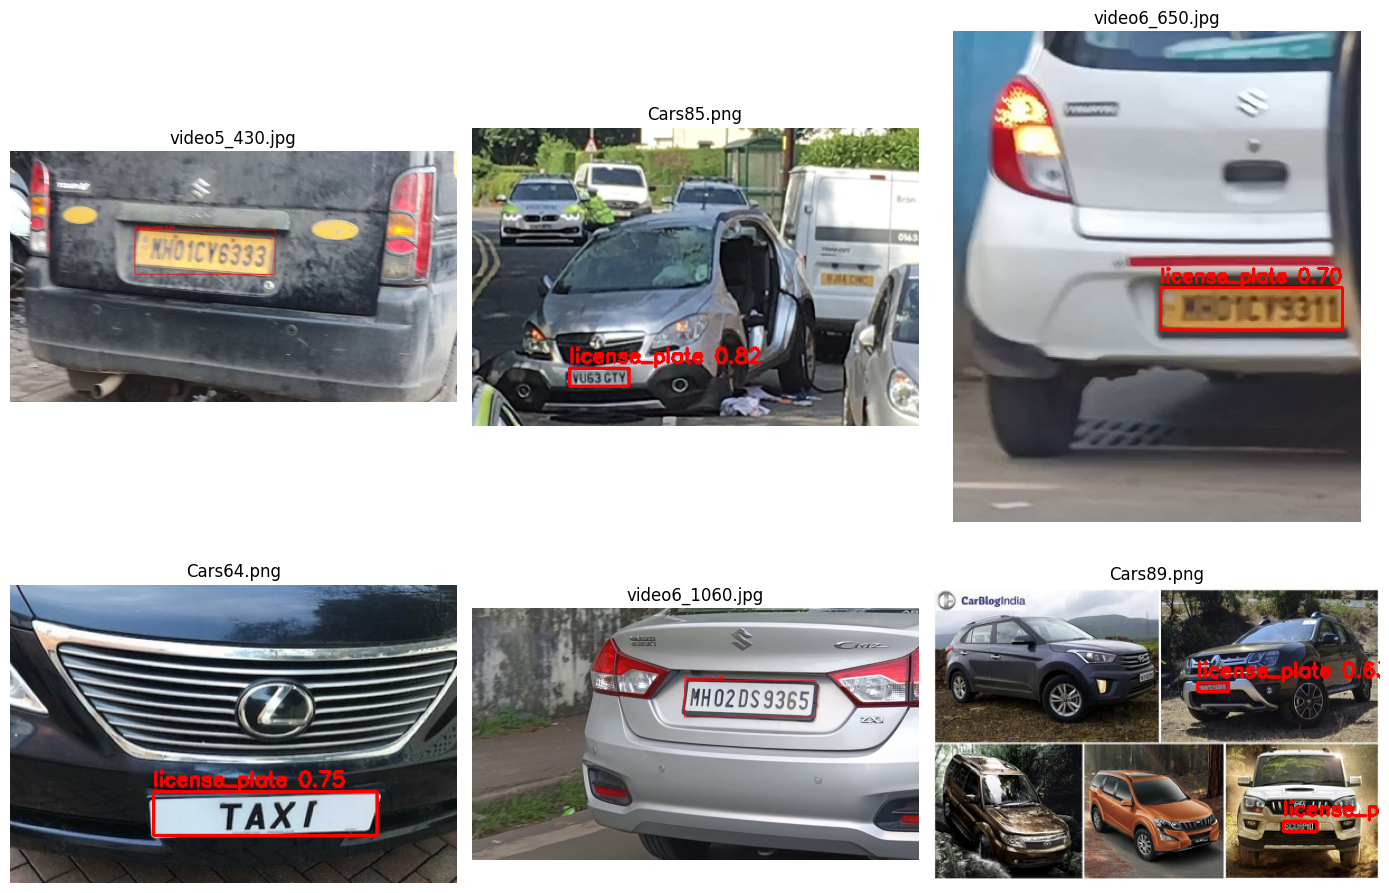

In [5]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
MODEL_PATH = "runs/lp_train/weights/best.torchscript"   # UPDATED PATH
DATASET_ROOT = "combined_yolo_lp"
VAL_IMG_DIR = Path(DATASET_ROOT) / "images" / "val"

# Load YOLO model
model = YOLO(MODEL_PATH)
print("Loaded model:", MODEL_PATH)

# Collect validation images
val_images = sorted(list(VAL_IMG_DIR.glob("*.*")))
print("Validation images:", len(val_images))

# ---------------------------------------------------------
# Draw detections
# ---------------------------------------------------------
def draw_yolo_predictions(img_rgb, boxes, confs, cls_ids, class_names):
    img = img_rgb.copy()

    for box, conf, cls_id in zip(boxes, confs, cls_ids):
        x1, y1, x2, y2 = map(int, box)
        label = f"{class_names[int(cls_id)]} {conf:.2f}"

        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(
            img, label,
            (x1, max(0, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6, (255, 0, 0), 2
        )

    return img

# ---------------------------------------------------------
# Run inference on random validation samples
# ---------------------------------------------------------
N = 6
sample_imgs = random.sample(val_images, N)

plt.figure(figsize=(14, 10))

for i, img_path in enumerate(sample_imgs):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # YOLO inference
    results = model(img_rgb, verbose=False)[0]

    boxes = results.boxes.xyxy.cpu().numpy()
    confs = results.boxes.conf.cpu().numpy()
    cls_ids = results.boxes.cls.cpu().numpy()
    class_names = results.names

    drawn = draw_yolo_predictions(img_rgb, boxes, confs, cls_ids, class_names)

    plt.subplot(2, 3, i + 1)
    plt.imshow(drawn)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()


WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.


Using CPU. Note: This module is much faster with a GPU.


Loaded YOLO model: runs/lp_train/weights/best.torchscript
EasyOCR initialized.
Validation images: 256
Loading runs/lp_train/weights/best.torchscript for TorchScript inference...


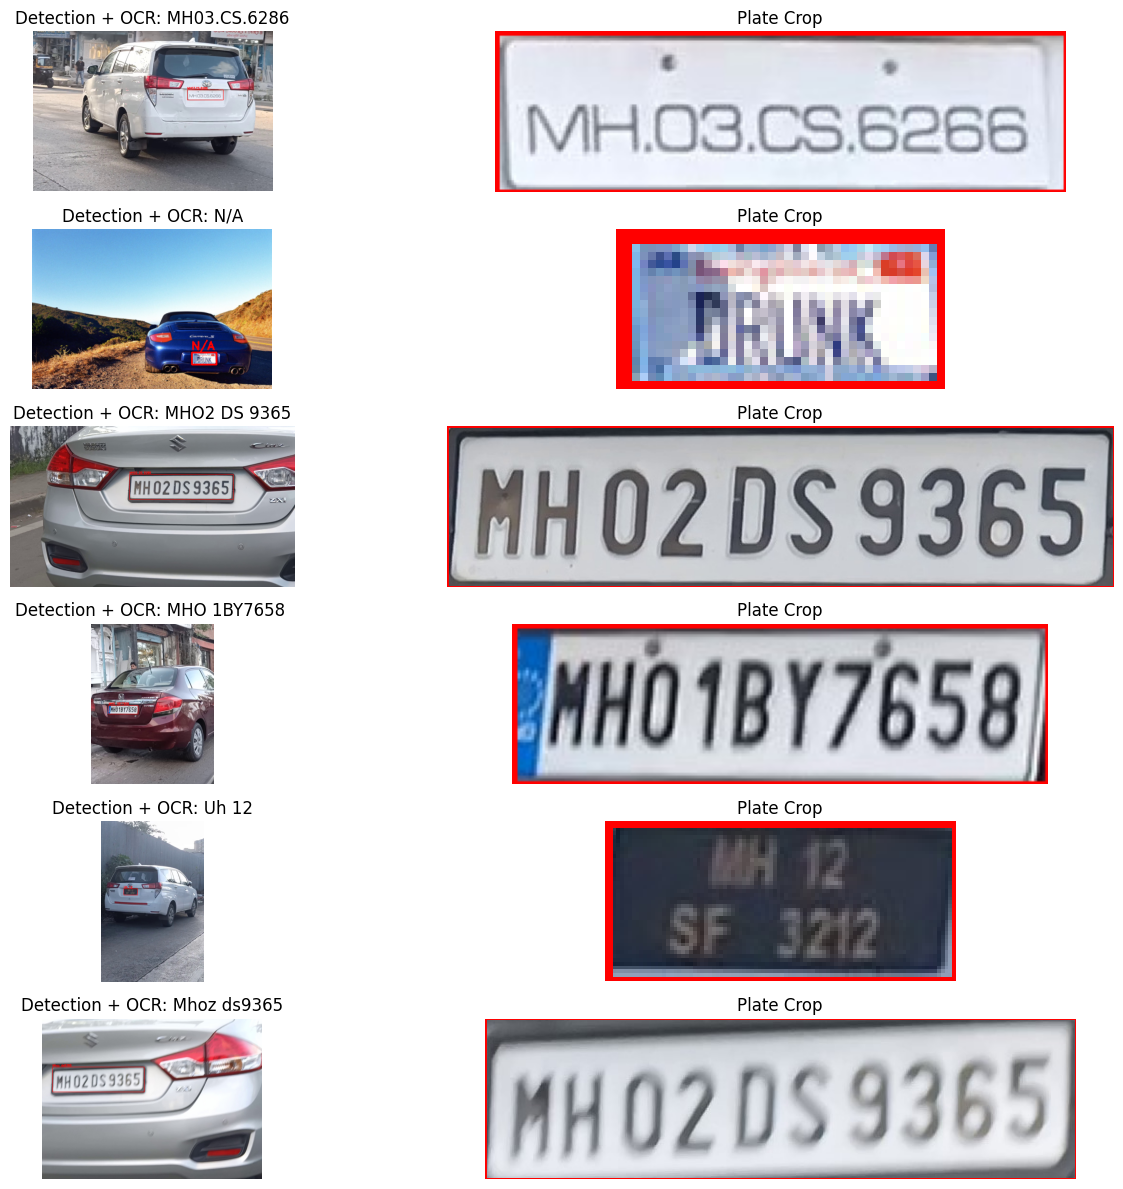

In [5]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import easyocr

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
MODEL_PATH = "runs/lp_train/weights/best.torchscript" 
DATASET_ROOT = "combined_yolo_lp"
VAL_IMG_DIR = Path(DATASET_ROOT) / "images/val"

# Load YOLO model
model = YOLO(MODEL_PATH)
print("Loaded YOLO model:", MODEL_PATH)

# Load EasyOCR reader (English)
reader = easyocr.Reader(['en'], gpu=False)
print("EasyOCR initialized.")

# Get validation images
val_images = sorted(list(VAL_IMG_DIR.glob("*.*")))
print("Validation images:", len(val_images))

# ---------------------------------------------------------
# Helper — crop YOLO bbox safely
# ---------------------------------------------------------
def crop_box(img, box):
    h, w = img.shape[:2]
    x1, y1, x2, y2 = map(int, box)
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)
    return img[y1:y2, x1:x2]

# ---------------------------------------------------------
# Run inference + OCR
# ---------------------------------------------------------
N = 6
sample_imgs = random.sample(val_images, N)

plt.figure(figsize=(14, 12))

for i, img_path in enumerate(sample_imgs):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # YOLO inference
    res = model(img_rgb, verbose=False)[0]

    boxes = res.boxes.xyxy.cpu().numpy()
    confs = res.boxes.conf.cpu().numpy()

    ocr_text = "N/A"
    plate_crop = None

    if len(boxes) > 0:
        # Use highest-confidence box
        best_idx = np.argmax(confs)
        box = boxes[best_idx]

        # Crop
        plate_crop = crop_box(img_rgb, box)

        # Run OCR if crop is large enough
        if plate_crop.size > 0:
            gray = cv2.cvtColor(plate_crop, cv2.COLOR_RGB2GRAY)
            results = reader.readtext(gray)

            if len(results) > 0:
                # Take first text result only
                ocr_text = results[0][1]

        # Draw box on original
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(
            img_rgb, f"{ocr_text}",
            (x1, max(0, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6, (255, 0, 0), 2
        )

    # Plot result
    plt.subplot(N, 2, 2*i + 1)
    plt.imshow(img_rgb)
    plt.title(f"Detection + OCR: {ocr_text}")
    plt.axis("off")

    plt.subplot(N, 2, 2*i + 2)
    if plate_crop is not None:
        plt.imshow(plate_crop if plate_crop.size > 0 else np.zeros((50,50,3), dtype=np.uint8))
        plt.title("Plate Crop")
    else:
        plt.imshow(np.zeros((50,50,3), dtype=np.uint8))
        plt.title("No Detection")
    plt.axis("off")

plt.tight_layout()
plt.show()
